# AON snRNA-seq Preprocessing

Single-nucleus RNA sequencing preprocessing pipeline for mouse Anterior Olfactory Nucleus (AON) tissue.

Includes ambient RNA decontamination via [DecontX](https://github.com/NiRuff/decontx-python) to correct for cytoplasmic contamination inherent to snRNA-seq.

**Input**: 10X Genomics Cell Ranger output (`filtered_feature_bc_matrix.h5`)
**Output**: Post-DecontX checkpoint (`AON_post_decontx.h5ad`) for downstream clustering in `02_clustering.ipynb`

In [1]:
from pathlib import Path

import decontx
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import yaml

sc.settings.set_figure_params(dpi=80, facecolor="white")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
ROOT = Path("..")
with open(ROOT / "config/config.yaml") as fh:
    cfg = yaml.safe_load(fh)
paths = cfg["paths"]
qc = cfg["qc"]
decontx_cfg = cfg["decontx"]

INPUT_H5 = ROOT / paths["aon_10x"]
POST_DECONTX = ROOT / paths["aon_post_decontx"]

OUTPUT_DIR = ROOT / paths["results_dir"]
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR = OUTPUT_DIR / "figures_raw"
TAB_DIR = OUTPUT_DIR / "tables"
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

## Data loading

Load the 10X Cell Ranger filtered feature-barcode matrix. This contains only cell-associated barcodes (droplets that Cell Ranger determined to contain a cell).

In [3]:
adata = sc.read_10x_h5(INPUT_H5)
adata.var_names_make_unique()
adata

anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


anndata/_core/anndata.py:1808: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 36863 × 32285
    var: 'gene_ids', 'feature_types', 'genome'

## Quality control

Flag mitochondrial (`mt-`) and ribosomal (`Rps`/`Rpl`) genes so their per-nucleus fractions feed the QC metrics below.

In [4]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo"], inplace=True, log1p=True
)

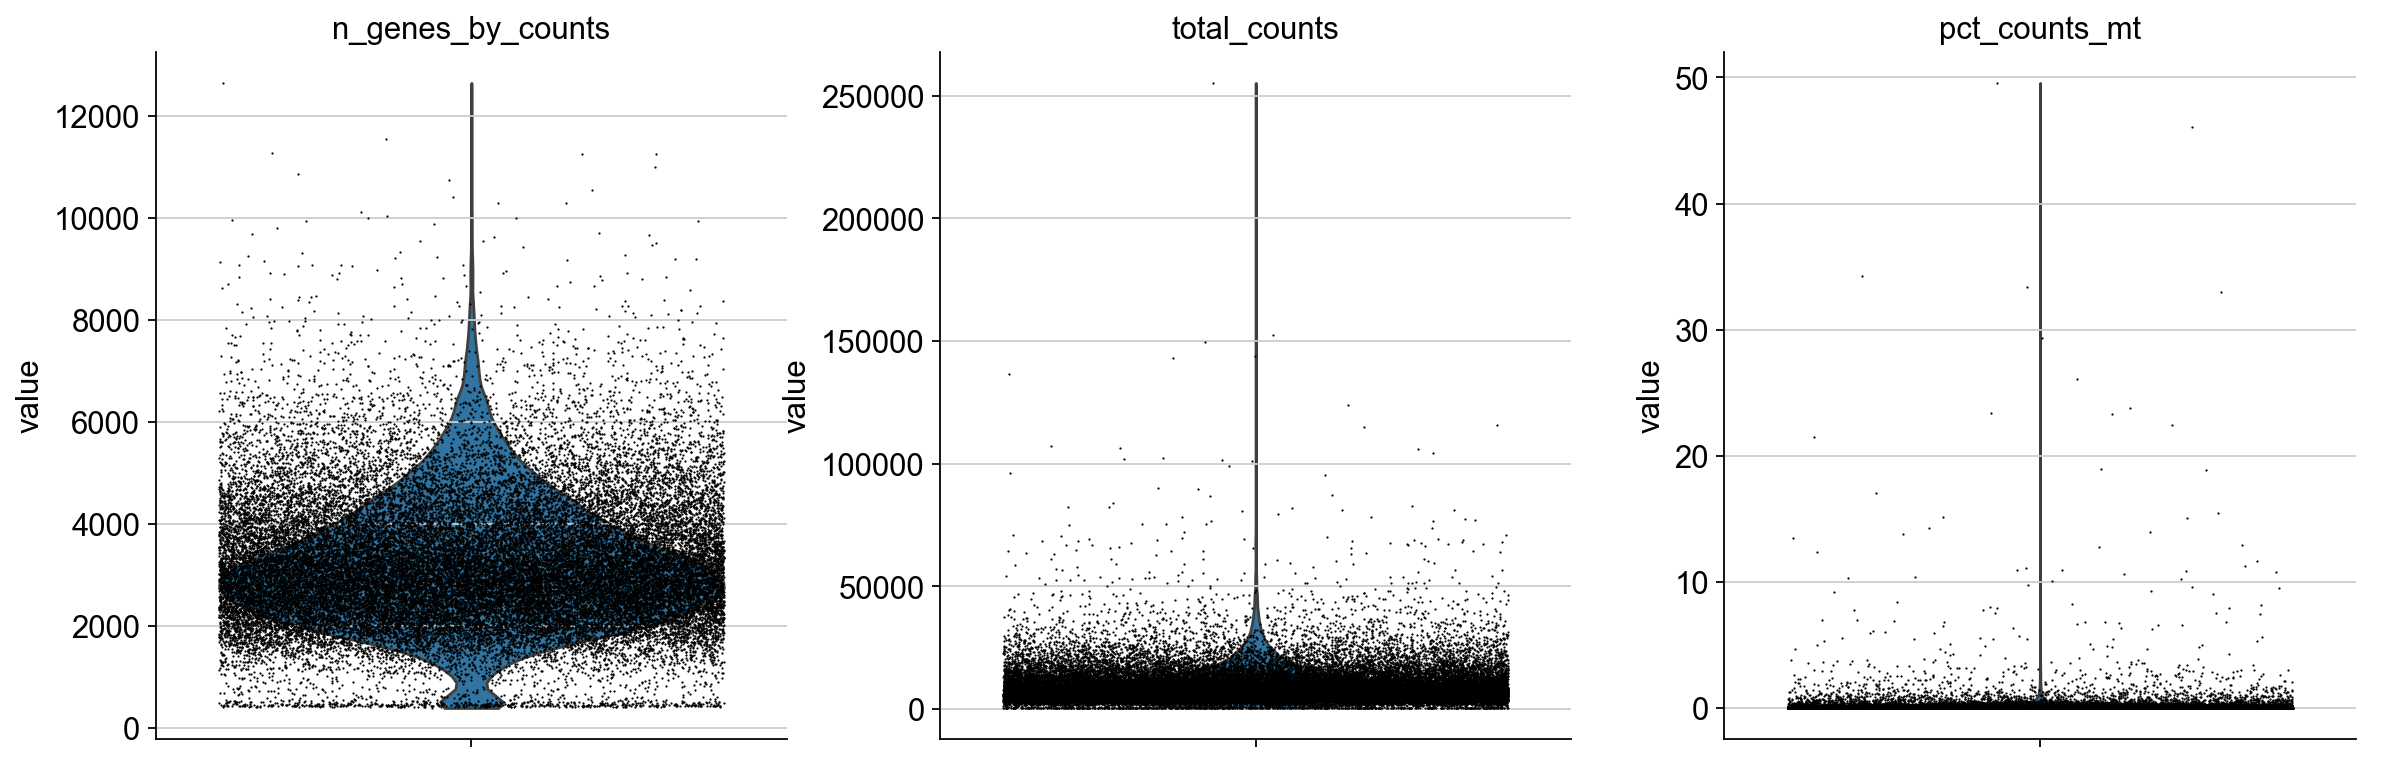

In [5]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

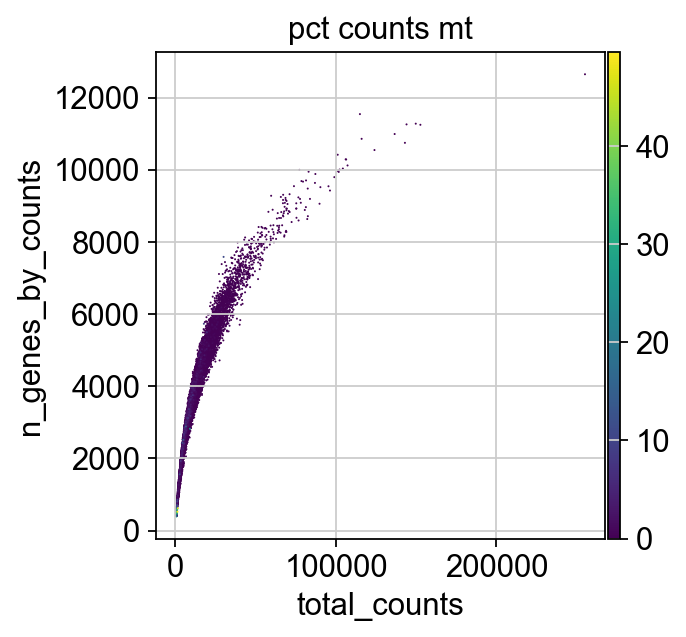

In [6]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

Distribution-derived reference bounds (median +/- 3 MAD) vs chosen cutoffs:
  genes/nucleus : data 992-9334      chosen 500-6000
  pct_mt        : data upper 0.13%      chosen 2.00%
  median pct_mt : 0.03%


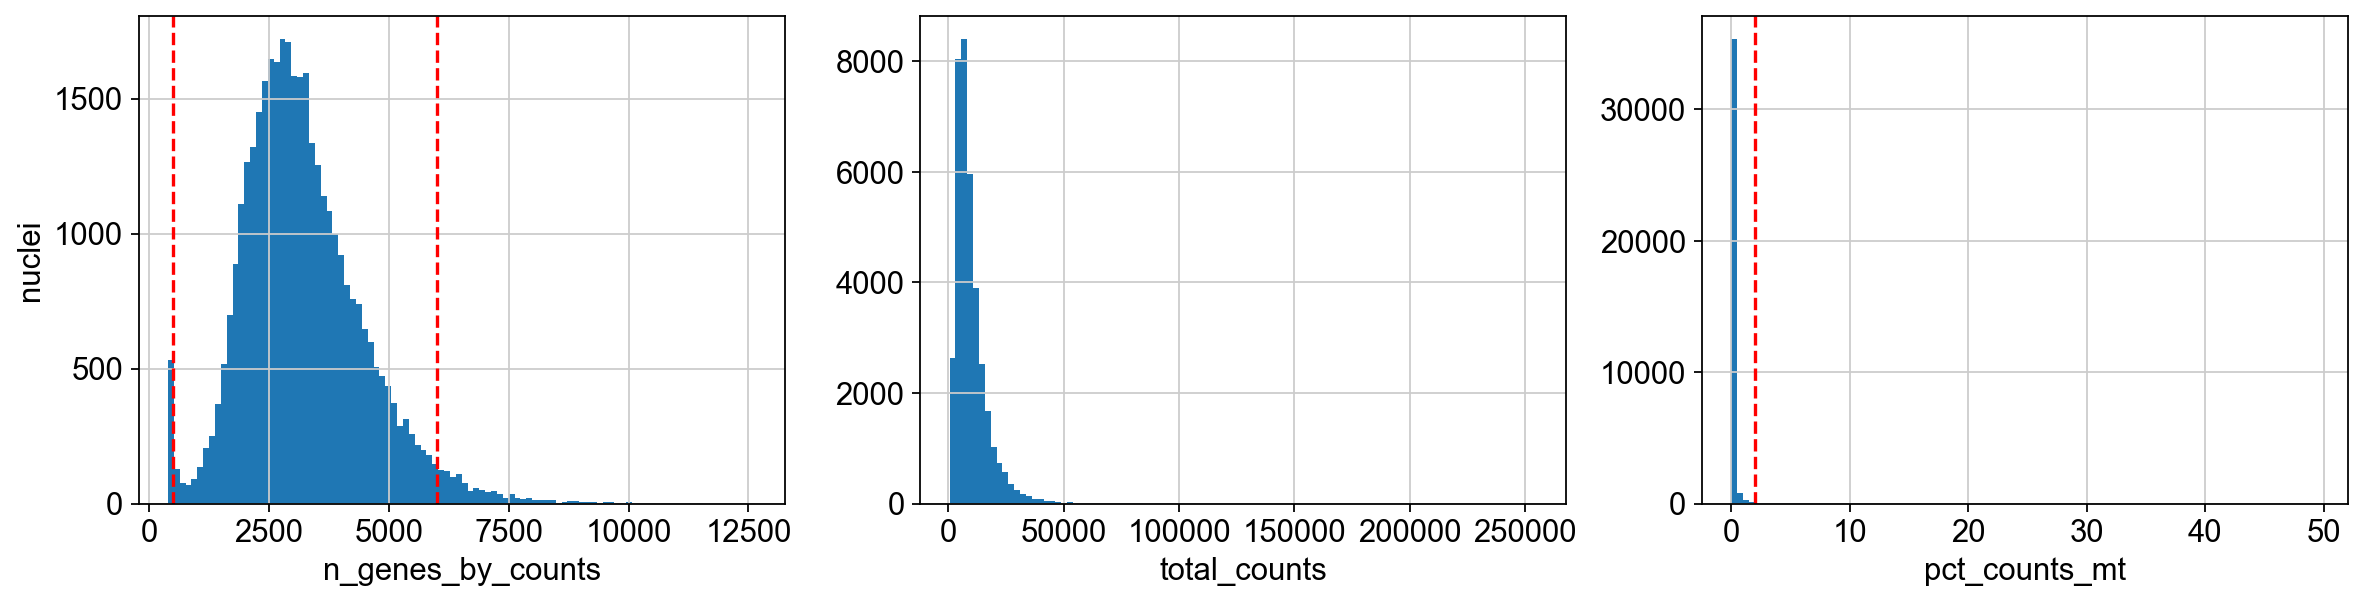

In [7]:
def mad_interval(values, n_mad=3):
    """Robust median +/- n_mad scaled-MAD interval for a 1D array."""
    med = np.median(values)
    mad = np.median(np.abs(values - med)) * 1.4826
    return med - n_mad * mad, med + n_mad * mad


log_genes = np.log1p(adata.obs["n_genes_by_counts"].values)
g_lo, g_hi = (np.expm1(b) for b in mad_interval(log_genes))
_, mt_hi = mad_interval(adata.obs["pct_counts_mt"].values)

print("Distribution-derived reference bounds (median +/- 3 MAD) vs chosen cutoffs:")
print(f"  genes/nucleus : data {g_lo:.0f}-{g_hi:.0f}      chosen {qc['min_genes']}-{qc['max_genes']}")
print(f"  pct_mt        : data upper {mt_hi:.2f}%      chosen {qc['pct_counts_mt']:.2f}%")
print(f"  median pct_mt : {np.median(adata.obs['pct_counts_mt']):.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, cuts) in zip(
    axes,
    [("n_genes_by_counts", [qc["min_genes"], qc["max_genes"]]),
     ("total_counts", []),
     ("pct_counts_mt", [qc["pct_counts_mt"]])],
):
    ax.hist(adata.obs[col], bins=100)
    for c in cuts:
        ax.axvline(c, color="red", linestyle="--")
    ax.set_xlabel(col)
axes[0].set_ylabel("nuclei")
plt.tight_layout()
plt.show()

### Cell and gene filtering

Cutoffs are read off the distributions above and cross-checked against the median +/- 3 MAD
reference in the previous cell:

- `min_genes=500`: removes empty droplets and debris, and sits well below the bulk of real
  nuclei.
- `max_genes=6000`: trims the high tail of likely multiplets while keeping the main
  population.
- `pct_counts_mt < 2%`: this is single-*nucleus* data. Nuclei are stripped of cytoplasm, so
  high mito flags damaged nuclei or ambient contamination. A strict cut is appropriate here,
  versus the 5-10% used for whole-cell tissue.
- `min_cells=3`: drops genes detected in fewer than 3 nuclei.

In [8]:
print(f"Cells before filtering: {adata.n_obs}")
print(f"Genes before filtering: {adata.n_vars}")

sc.pp.filter_cells(adata, min_genes=qc["min_genes"])
sc.pp.filter_cells(adata, max_genes=qc["max_genes"])
adata = adata[adata.obs.pct_counts_mt < qc["pct_counts_mt"], :].copy()
sc.pp.filter_genes(adata, min_cells=qc["min_cells"])

print(f"Cells after filtering: {adata.n_obs}")
print(f"Genes after filtering: {adata.n_vars}")

Cells before filtering: 36863
Genes before filtering: 32285


Cells after filtering: 35028
Genes after filtering: 26136


## Ambient RNA removal

Ambient RNA from lysed cells leaks into the droplets, and in brain tissue that pool is mostly neuronal (OSCA Bioconductor), so non-neuronal nuclei pick up spurious neuronal markers. DecontX estimates each nucleus's ambient fraction from the surrounding clusters and subtracts it, so it needs a preliminary clustering first.

### Preliminary clustering for DecontX

Run a quick normalize-cluster pass on raw counts to provide cluster labels for DecontX. These clusters are temporary and discarded after decontamination.

In [9]:
adata.layers["counts_raw"] = adata.X.copy()

adata_prelim = adata.copy()
sc.pp.normalize_total(adata_prelim)
sc.pp.log1p(adata_prelim)
sc.pp.highly_variable_genes(adata_prelim, n_top_genes=2000)
sc.tl.pca(adata_prelim, random_state=42)
sc.pp.neighbors(adata_prelim, n_pcs=30, random_state=42)
sc.tl.leiden(adata_prelim, resolution=0.5, flavor="igraph", n_iterations=2,
            key_added="leiden_prelim", random_state=42)

adata.obs["leiden_prelim"] = adata_prelim.obs["leiden_prelim"]
del adata_prelim

print(f"Preliminary clusters: {adata.obs['leiden_prelim'].nunique()}")

Preliminary clusters: 23


### Run DecontX

Run DecontX on the raw counts with the preliminary clusters. It returns a per-nucleus contamination estimate and decontaminated counts.

In [10]:
# decontx-python is single-threaded (~90s/iteration on this dataset), so the run is capped at
# 120 iterations with a relaxed 0.0025 convergence tolerance to keep the runtime near three
# hours. At the cap the run stops just short of convergence, so the reported ~27% mean
# contamination is a conservative upper bound.
decontx.decontx(adata, cluster_key="leiden_prelim", convergence=0.0025, max_iter=decontx_cfg["max_iter"])

contamination = adata.obs["decontX_contamination"]
print(f"Mean contamination: {contamination.mean():.1%}")
print(f"Median contamination: {contamination.median():.1%}")
print(f"95th percentile: {contamination.quantile(0.95):.1%}")

Starting DecontX
Processing 35028 cells, 26136 genes
Using 23 clusters from 'leiden_prelim'
Processing as single batch


Iter 0: LL=-2501990186.4, change=0.1601, mean_contam=0.481


Iter 10: LL=-2497825995.0, change=0.0318, mean_contam=0.397


Iter 20: LL=-2497306485.9, change=0.0147, mean_contam=0.362


Iter 30: LL=-2497096306.1, change=0.0108, mean_contam=0.339


...

Iter 80: LL=-2496758642.4, change=0.0045, mean_contam=0.280


Iter 90: LL=-2496736097.3, change=0.0038, mean_contam=0.274


Iter 100: LL=-2496716851.9, change=0.0033, mean_contam=0.270


Iter 110: LL=-2496701503.6, change=0.0029, mean_contam=0.265


Mean contamination: 26.2%
Highly contaminated cells (>50%): 4893
Completed DecontX in 1:48:42.593173
Mean contamination: 26.2%
Median contamination: 19.3%
95th percentile: 67.8%


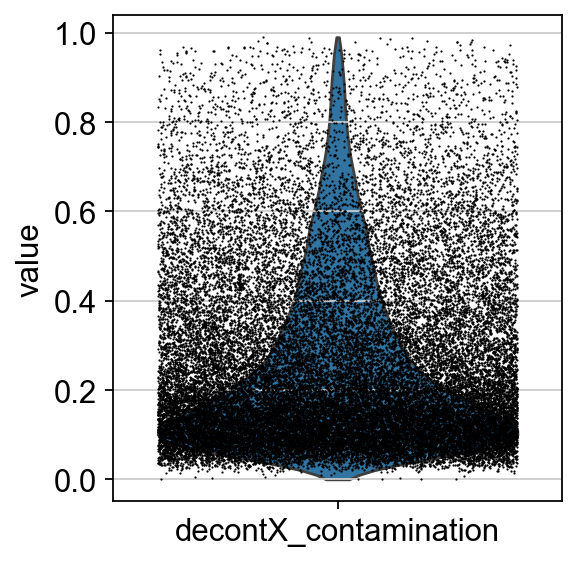

In [11]:
sc.pl.violin(adata, "decontX_contamination", jitter=0.4)

In [12]:
adata.layers["counts"] = adata.layers["decontX_counts"].copy()
adata.X = adata.layers["decontX_counts"].copy()

## Checkpoint

Save after DecontX to avoid re-running the multi-hour step. Resume from this checkpoint in `02_clustering.ipynb`.

In [13]:
keys_to_remove = [k for k in adata.uns if k.startswith("decontX")]
for k in keys_to_remove:
    del adata.uns[k]

checkpoint_path = POST_DECONTX
adata.write(checkpoint_path, compression="gzip")
print(f"Checkpoint saved to {checkpoint_path}")
print(f"Shape: {adata.n_obs} cells, {adata.n_vars} genes")

Checkpoint saved to ../data/aon_10x/AON_post_decontx.h5ad
Shape: 35028 cells, 26136 genes
